In [2]:
!pip install xgboost shap openpyxl plotly -q

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go


from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")
from google.colab import files

In [4]:
#Dataset upload
uploaded = files.upload()

file_path = list(uploaded.keys())[0]

df = pd.read_excel(file_path)


print("Dataset Loaded Successfully")



Saving dataset....xlsx to dataset....xlsx
Dataset Loaded Successfully


In [5]:
#basic info
print("Dataset Shape:")
print(df.shape)


print("\nColumns:")
print(df.columns)



df.head()

Dataset Shape:
(1000, 13)

Columns:
Index(['Product_ID', 'Warehouse', 'Supplier', 'Order_Date', 'Delivery_Date',
       'Demand', 'Inventory', 'Lead_Time', 'Transportation_Cost', 'Sales',
       'Weather', 'Fuel_Price', 'Delay'],
      dtype='object')


,Product_ID,Warehouse,Supplier,Order_Date,Delivery_Date,Demand,Inventory,Lead_Time,Transportation_Cost,Sales,Weather,Fuel_Price,Delay
0,P0001,South,C,2025-02-16,2025-02-24,226,402,7,3418.44,226,Cloudy,1.96,Yes
1,P0002,South,A,2025-03-19,2025-03-23,351,110,3,1271.37,110,Sunny,1.95,Yes
2,P0003,West,B,2025-12-08,2025-12-20,51,562,10,1312.09,51,Cloudy,1.56,Yes
3,P0004,North,B,2025-08-10,2025-08-20,86,29,7,4708.03,29,Rain,2.34,Yes
4,P0005,East,A,2025-05-04,2025-05-14,111,419,8,1061.69,111,Cloudy,1.36,Yes


In [6]:
# Missing Values

print("Missing Values")

print(df.isnull().sum())



# Duplicate Rows

print("\nDuplicates:")

print(df.duplicated().sum())
# Remove duplicates

df.drop_duplicates(inplace=True)



# Data Types

df.info()

Missing Values
Product_ID             0
Warehouse              0
Supplier               0
Order_Date             0
Delivery_Date          0
Demand                 0
Inventory              0
Lead_Time              0
Transportation_Cost    0
Sales                  0
Weather                0
Fuel_Price             0
Delay                  0
dtype: int64

Duplicates:
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Product_ID           1000 non-null   object 
 1   Warehouse            1000 non-null   object 
 2   Supplier             1000 non-null   object 
 3   Order_Date           1000 non-null   object 
 4   Delivery_Date        1000 non-null   object 
 5   Demand               1000 non-null   int64  
 6   Inventory            1000 non-null   int64  
 7   Lead_Time            1000 non-null   int64  
 8   Transportation_Cost  

In [7]:
df['Order_Date'] = pd.to_datetime(
    df['Order_Date']
)


df['Delivery_Date'] = pd.to_datetime(
    df['Delivery_Date']
)

# Date Features

df['Order_Day'] = df['Order_Date'].dt.day

df['Order_Month'] = df['Order_Date'].dt.month

df['Order_Year'] = df['Order_Date'].dt.year

# Delivery Time

df['Actual_Delivery_Time'] = (
    df['Delivery_Date']
    -
    df['Order_Date']
).dt.days



df.head()

,Product_ID,Warehouse,Supplier,Order_Date,Delivery_Date,Demand,Inventory,Lead_Time,Transportation_Cost,Sales,Weather,Fuel_Price,Delay,Order_Day,Order_Month,Order_Year,Actual_Delivery_Time
0,P0001,South,C,2025-02-16,2025-02-24,226,402,7,3418.44,226,Cloudy,1.96,Yes,16,2,2025,8
1,P0002,South,A,2025-03-19,2025-03-23,351,110,3,1271.37,110,Sunny,1.95,Yes,19,3,2025,4
2,P0003,West,B,2025-12-08,2025-12-20,51,562,10,1312.09,51,Cloudy,1.56,Yes,8,12,2025,12
3,P0004,North,B,2025-08-10,2025-08-20,86,29,7,4708.03,29,Rain,2.34,Yes,10,8,2025,10
4,P0005,East,A,2025-05-04,2025-05-14,111,419,8,1061.69,111,Cloudy,1.36,Yes,4,5,2025,10


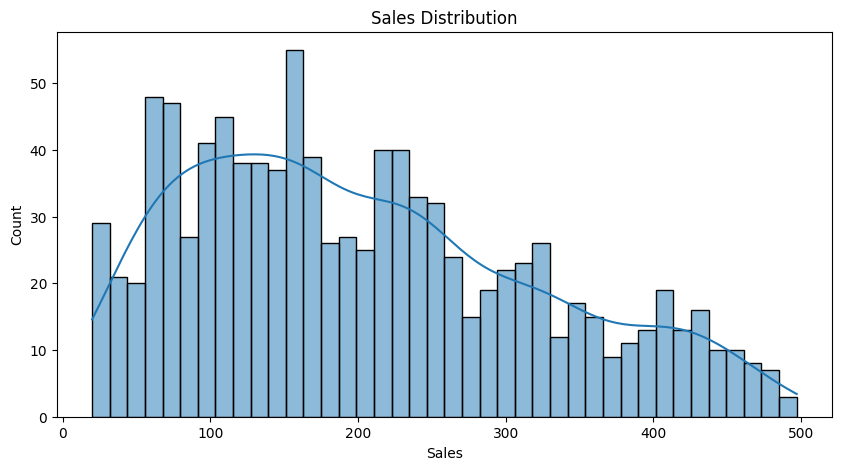

In [8]:
#sales analysis
plt.figure(figsize=(10,5))


sns.histplot(
    df['Sales'],
    bins=40,
    kde=True
)


plt.title(
    "Sales Distribution"
)


plt.show()

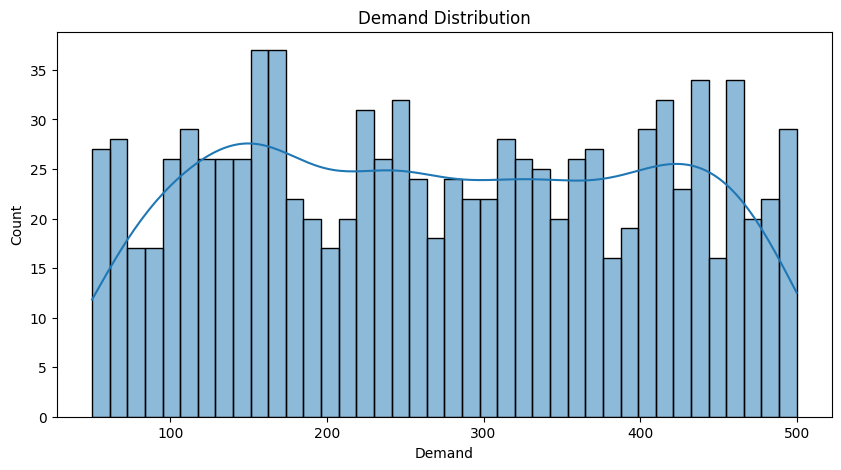

In [9]:
#demand analysis
plt.figure(figsize=(10,5))


sns.histplot(
    df['Demand'],
    bins=40,
    kde=True
)


plt.title(
    "Demand Distribution"
)


plt.show()

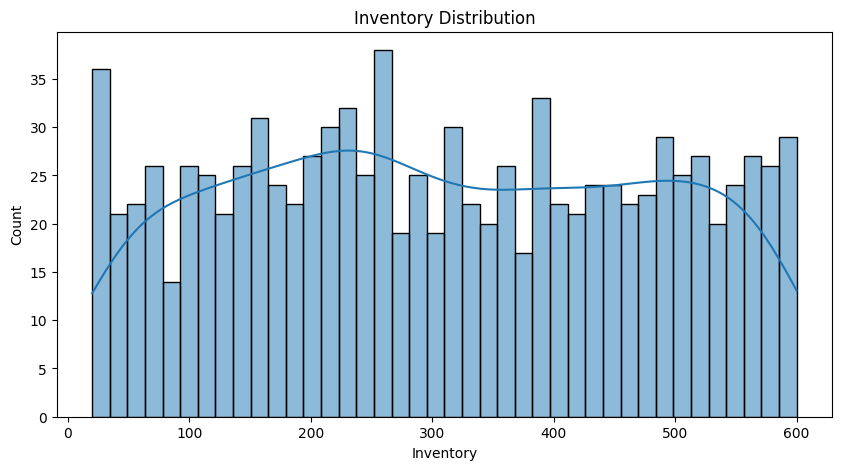

In [10]:
#inventory analysis
plt.figure(figsize=(10,5))


sns.histplot(
    df['Inventory'],
    bins=40,
    kde=True
)


plt.title(
    "Inventory Distribution"
)


plt.show()

In [11]:
#warehouse peerformance
warehouse = (
    df.groupby('Warehouse')
    ['Sales']
    .sum()
    .reset_index()
)


fig = px.bar(
    warehouse,
    x='Warehouse',
    y='Sales',
    title="Sales by Warehouse"
)


fig.show()

In [12]:
#supplier analysis
supplier = (
    df.groupby('Supplier')
    .agg(
        Orders=('Product_ID','count'),
        Average_Lead_Time=('Lead_Time','mean'),
        Average_Cost=('Transportation_Cost','mean')
    )
    .reset_index()
)


supplier

,Supplier,Orders,Average_Lead_Time,Average_Cost
0,A,222,5.157658,2645.962748
1,B,255,5.584314,2761.578118
2,C,259,6.023166,2640.550927
3,D,264,5.594697,2461.020606


In [13]:
#deliery delay analysis
delay = df['Delay'].value_counts()


fig = px.pie(
    values=delay.values,
    names=delay.index,
    title="Delivery Delay Analysis"
)


fig.show()

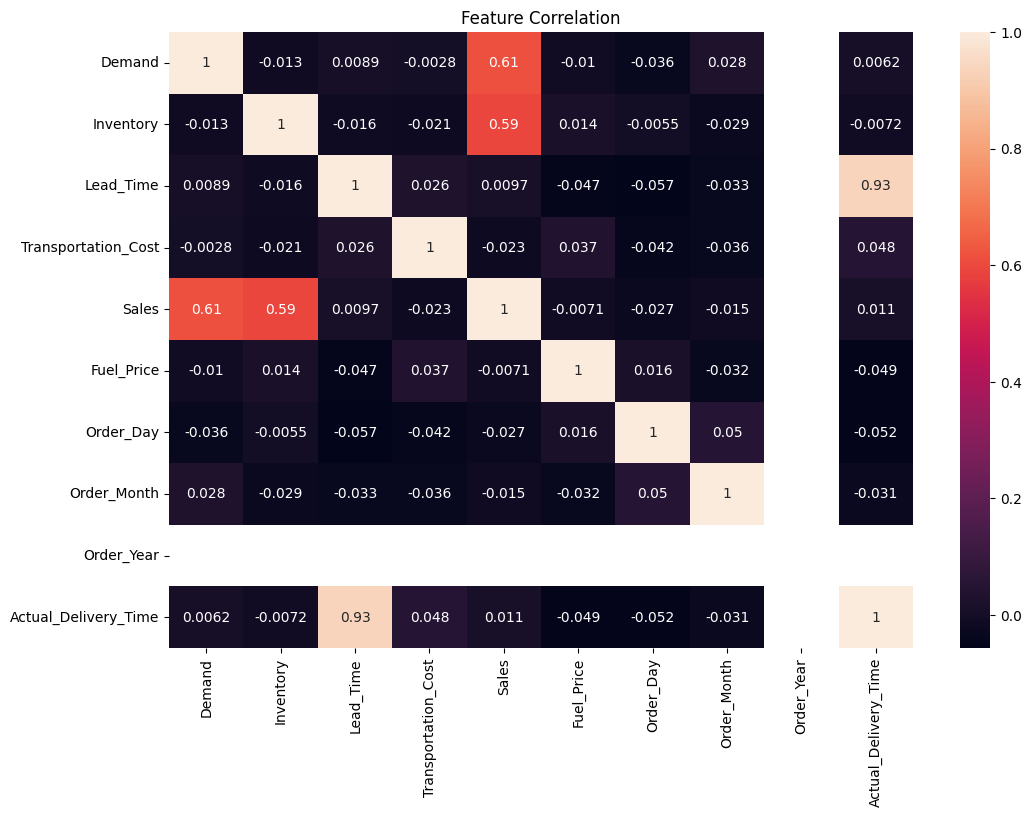

In [14]:
#coorelation analysis
plt.figure(figsize=(12,8))


sns.heatmap(
    df.select_dtypes(
        include=np.number
    ).corr(),
    annot=True
)


plt.title(
    "Feature Correlation"
)


plt.show()

In [15]:
#Feature engeenering
# Inventory Risk

df['Inventory_Risk'] = np.where(
    df['Inventory'] < df['Demand'],
    1,
    0
)
# Cost per unit

df['Cost_Per_Unit'] = (
    df['Transportation_Cost']
    /
    df['Sales']
)
# Delivery Performance

df['Delivery_Performance'] = (
    df['Lead_Time']
    -
    df['Actual_Delivery_Time']
)


# Demand Category

df['Demand_Category'] = pd.cut(
    df['Demand'],
    bins=3,
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)



df.head()

,Product_ID,Warehouse,Supplier,Order_Date,Delivery_Date,Demand,Inventory,Lead_Time,Transportation_Cost,Sales,...,Fuel_Price,Delay,Order_Day,Order_Month,Order_Year,Actual_Delivery_Time,Inventory_Risk,Cost_Per_Unit,Delivery_Performance,Demand_Category
0,P0001,South,C,2025-02-16,2025-02-24,226,402,7,3418.44,226,...,1.96,Yes,16,2,2025,8,0,15.125841,-1,Medium
1,P0002,South,A,2025-03-19,2025-03-23,351,110,3,1271.37,110,...,1.95,Yes,19,3,2025,4,1,11.557909,-1,High
2,P0003,West,B,2025-12-08,2025-12-20,51,562,10,1312.09,51,...,1.56,Yes,8,12,2025,12,0,25.727255,-2,Low
3,P0004,North,B,2025-08-10,2025-08-20,86,29,7,4708.03,29,...,2.34,Yes,10,8,2025,10,1,162.345862,-3,Low
4,P0005,East,A,2025-05-04,2025-05-14,111,419,8,1061.69,111,...,1.36,Yes,4,5,2025,10,0,9.564775,-2,Low


In [16]:
#encode categorical data
#label encoding
encoder = LabelEncoder()


categorical_columns = [
    'Warehouse',
    'Supplier',
    'Weather',
    'Delay',
    'Demand_Category'
]


for col in categorical_columns:

    df[col] = encoder.fit_transform(
        df[col].astype(str)
        )


df.head()

,Product_ID,Warehouse,Supplier,Order_Date,Delivery_Date,Demand,Inventory,Lead_Time,Transportation_Cost,Sales,...,Fuel_Price,Delay,Order_Day,Order_Month,Order_Year,Actual_Delivery_Time,Inventory_Risk,Cost_Per_Unit,Delivery_Performance,Demand_Category
0,P0001,2,2,2025-02-16,2025-02-24,226,402,7,3418.44,226,...,1.96,1,16,2,2025,8,0,15.125841,-1,2
1,P0002,2,0,2025-03-19,2025-03-23,351,110,3,1271.37,110,...,1.95,1,19,3,2025,4,1,11.557909,-1,0
2,P0003,3,1,2025-12-08,2025-12-20,51,562,10,1312.09,51,...,1.56,1,8,12,2025,12,0,25.727255,-2,1
3,P0004,1,1,2025-08-10,2025-08-20,86,29,7,4708.03,29,...,2.34,1,10,8,2025,10,1,162.345862,-3,1
4,P0005,0,0,2025-05-04,2025-05-14,111,419,8,1061.69,111,...,1.36,1,4,5,2025,10,0,9.564775,-2,1


In [17]:
# SAVE CLEAN DATA
df.to_excel(
    "Prepared_Supply_Chain_Data.xlsx",
    index=False
)




In [18]:
#demand forcasting using XGBOOST

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


from xgboost import XGBRegressor

import joblib


features = [

    'Inventory',
    'Lead_Time',
    'Transportation_Cost',
    'Fuel_Price',
    'Sales',
    'Weather',
    'Warehouse',
    'Supplier',
    'Order_Month',
    'Order_Year',
    'Actual_Delivery_Time',
    'Inventory_Risk',
    'Cost_Per_Unit',
    'Delivery_Performance'

]


target = "Demand"



X = df[features]

y = df[target]



print("Feature Shape:", X.shape)

print("Target Shape:", y.shape)

Feature Shape: (1000, 14)
Target Shape: (1000,)


In [19]:

# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42

)



print(
    "Training Data:",
    X_train.shape
)


print(
    "Testing Data:",
    X_test.shape
)

Training Data: (800, 14)
Testing Data: (200, 14)


In [20]:

# MODEL PREDICTION

# Initialize and train the XGBoost Regressor model
model_demand = XGBRegressor(
    n_estimators=100,  # Number of boosting rounds
    learning_rate=0.1,  # Step size shrinkage to prevent overfitting
    random_state=42
)

model_demand.fit(X_train, y_train)


y_pred = model_demand.predict(
    X_test
)


prediction_result = pd.DataFrame({

    "Actual_Demand": y_test,

    "Predicted_Demand": y_pred

})


prediction_result.head()


,Actual_Demand,Predicted_Demand
521,439,322.410522
737,481,179.360168
740,314,358.197601
660,316,317.574097
411,402,345.086578


In [21]:

# EVALUATION METRICS


mae = mean_absolute_error(

    y_test,

    y_pred

)


rmse = np.sqrt(

    mean_squared_error(

        y_test,

        y_pred

    )

)


r2 = r2_score(

    y_test,

    y_pred

)



print(
    "MAE:",
    round(mae,2)
)


print(
    "RMSE:",
    round(rmse,2)
)


print(
    "R2 Score:",
    round(r2,3)
)

MAE: 45.19
RMSE: 80.46
R2 Score: 0.634


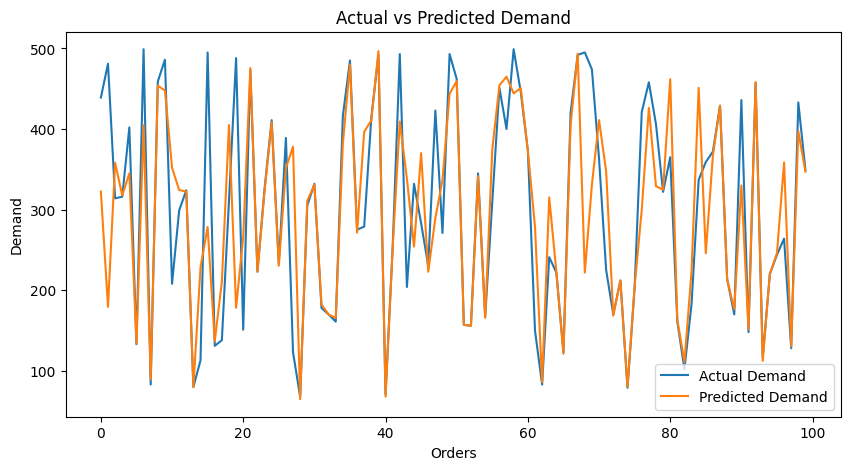

In [22]:

# ACTUAL S PREDICTIE DEMAND

plt.figure(figsize=(10,5))


plt.plot(

    y_test.values[:100],

    label="Actual Demand"

)


plt.plot(

    y_pred[:100],

    label="Predicted Demand"

)


plt.title(
    "Actual vs Predicted Demand"
)


plt.xlabel(
    "Orders"
)


plt.ylabel(
    "Demand"
)


plt.legend()


plt.show()

In [23]:

# FEATURE IMPORTANCE



importance = pd.DataFrame({

    "Feature":features,

    "Importance":
    model_demand.feature_importances_

})


importance = importance.sort_values(

    by="Importance",

    ascending=False

)


importance

,Feature,Importance
11,Inventory_Risk,0.483968
4,Sales,0.229664
6,Warehouse,0.036301
7,Supplier,0.034291
3,Fuel_Price,0.034139
12,Cost_Per_Unit,0.030779
13,Delivery_Performance,0.028461
2,Transportation_Cost,0.026267
8,Order_Month,0.024909
5,Weather,0.020507


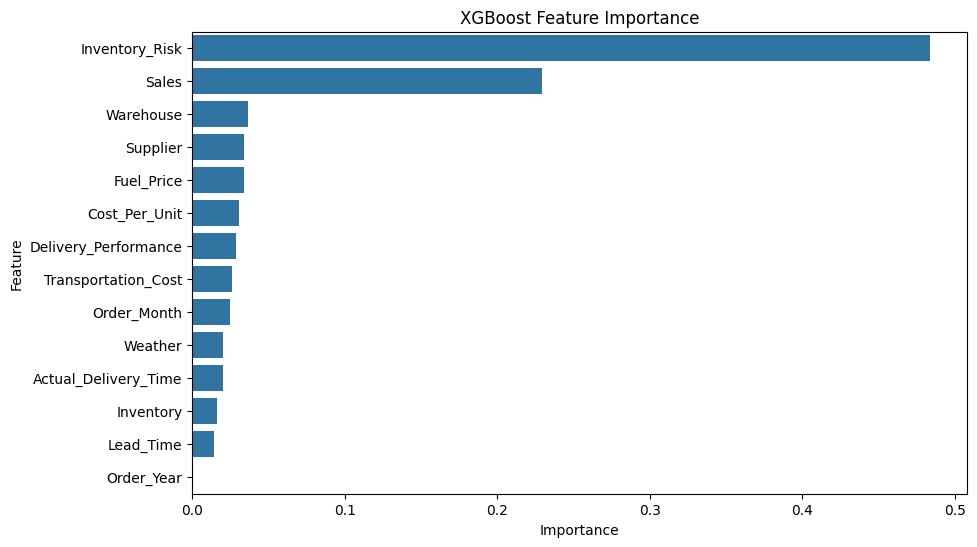

In [24]:
plt.figure(figsize=(10,6))


sns.barplot(

    data=importance,

    x="Importance",

    y="Feature"

)


plt.title(
    "XGBoost Feature Importance"
)


plt.show()

In [25]:

# FUTURE DEMAND PREDICTION FUNCTION



def predict_demand(data):

    prediction = model_demand.predict(
        data[features]
    )

    data["Predicted_Demand"] = prediction

    return data



future_prediction = predict_demand(
    df.copy()
)


future_prediction.head()

,Product_ID,Warehouse,Supplier,Order_Date,Delivery_Date,Demand,Inventory,Lead_Time,Transportation_Cost,Sales,...,Delay,Order_Day,Order_Month,Order_Year,Actual_Delivery_Time,Inventory_Risk,Cost_Per_Unit,Delivery_Performance,Demand_Category,Predicted_Demand
0,P0001,2,2,2025-02-16,2025-02-24,226,402,7,3418.44,226,...,1,16,2,2025,8,0,15.125841,-1,2,226.161530
1,P0002,2,0,2025-03-19,2025-03-23,351,110,3,1271.37,110,...,1,19,3,2025,4,1,11.557909,-1,0,356.093964
2,P0003,3,1,2025-12-08,2025-12-20,51,562,10,1312.09,51,...,1,8,12,2025,12,0,25.727255,-2,1,50.089405
3,P0004,1,1,2025-08-10,2025-08-20,86,29,7,4708.03,29,...,1,10,8,2025,10,1,162.345862,-3,1,95.238121
4,P0005,0,0,2025-05-04,2025-05-14,111,419,8,1061.69,111,...,1,4,5,2025,10,0,9.564775,-2,1,109.158287


In [26]:

# SAVE DEMAND MODEL


joblib.dump(

    model_demand,

    "Demand_Forecasting_XGBoost.pkl"

)


print(
    "Model Saved Successfully"
)

Model Saved Successfully


In [27]:

# EXPORT RESULTS



future_prediction.to_excel(

    "Demand_Forecast_Result.xlsx",

    index=False

)


print(
    "Forecast File Created"
)

Forecast File Created


In [1]:
# DELIVERY DELAY PREDICTION

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import joblib

In [28]:
# FEATURES

delay_features = [

    'Inventory',
    'Demand',
    'Lead_Time',
    'Transportation_Cost',
    'Fuel_Price',
    'Sales',
    'Warehouse',
    'Supplier',
    'Weather',
    'Order_Month',
    'Actual_Delivery_Time',
    'Inventory_Risk',
    'Cost_Per_Unit',
    'Delivery_Performance'

]
target = "Delay"

X = df[delay_features]

y = df[target]

print(X.shape)
print(y.shape)

(1000, 14)
(1000,)


In [29]:
# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [30]:

# RANDOM FOREST

rf_model = RandomForestClassifier(

    n_estimators=300,

    max_depth=10,

    random_state=42

)

rf_model.fit(

    X_train,

    y_train

)

rf_prediction = rf_model.predict(X_test)

print("Random Forest Model Trained")

Random Forest Model Trained


In [32]:

# XGBOOST CLASSIFIER

xgb_model = XGBClassifier(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=6,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42,

    eval_metric='logloss'

)

xgb_model.fit(

    X_train,

    y_train

)

xgb_prediction = xgb_model.predict(X_test)


In [33]:
# EVALUATION

accuracy = accuracy_score(

    y_test,

    xgb_prediction

)

precision = precision_score(

    y_test,

    xgb_prediction,

    zero_division=0

)
recall = recall_score(

    y_test,

    xgb_prediction,

    zero_division=0

)

f1 = f1_score(

    y_test,

    xgb_prediction,

    zero_division=0

)
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [34]:

# REPORT
print(

    classification_report(

        y_test,

        xgb_prediction

    )

)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        48
           1       1.00      1.00      1.00       152

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



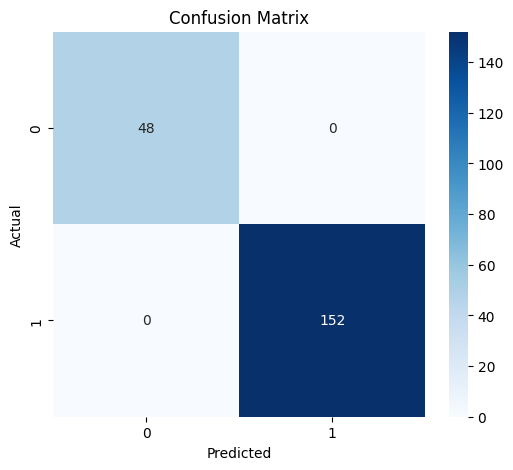

In [36]:

# CONFUSION MATRIX


cm = confusion_matrix(

    y_test,

    xgb_prediction

)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    cmap="Blues",

    fmt="d"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [37]:

# PROBABILITY

delay_probability = xgb_model.predict_proba(X)

df["Delay_Probability"] = delay_probability[:,1]

df.head()

,Product_ID,Warehouse,Supplier,Order_Date,Delivery_Date,Demand,Inventory,Lead_Time,Transportation_Cost,Sales,...,Delay,Order_Day,Order_Month,Order_Year,Actual_Delivery_Time,Inventory_Risk,Cost_Per_Unit,Delivery_Performance,Demand_Category,Delay_Probability
0,P0001,2,2,2025-02-16,2025-02-24,226,402,7,3418.44,226,...,1,16,2,2025,8,0,15.125841,-1,2,0.997410
1,P0002,2,0,2025-03-19,2025-03-23,351,110,3,1271.37,110,...,1,19,3,2025,4,1,11.557909,-1,0,0.997586
2,P0003,3,1,2025-12-08,2025-12-20,51,562,10,1312.09,51,...,1,8,12,2025,12,0,25.727255,-2,1,0.998530
3,P0004,1,1,2025-08-10,2025-08-20,86,29,7,4708.03,29,...,1,10,8,2025,10,1,162.345862,-3,1,0.998236
4,P0005,0,0,2025-05-04,2025-05-14,111,419,8,1061.69,111,...,1,4,5,2025,10,0,9.564775,-2,1,0.998208


In [38]:

# HIGH RISK SHIPMENTS

high_risk = df[
    df["Delay_Probability"] > 0.70
]

print(

    "High Risk Shipments:",

    len(high_risk)

)

high_risk.head()

High Risk Shipments: 759


,Product_ID,Warehouse,Supplier,Order_Date,Delivery_Date,Demand,Inventory,Lead_Time,Transportation_Cost,Sales,...,Delay,Order_Day,Order_Month,Order_Year,Actual_Delivery_Time,Inventory_Risk,Cost_Per_Unit,Delivery_Performance,Demand_Category,Delay_Probability
0,P0001,2,2,2025-02-16,2025-02-24,226,402,7,3418.44,226,...,1,16,2,2025,8,0,15.125841,-1,2,0.997410
1,P0002,2,0,2025-03-19,2025-03-23,351,110,3,1271.37,110,...,1,19,3,2025,4,1,11.557909,-1,0,0.997586
2,P0003,3,1,2025-12-08,2025-12-20,51,562,10,1312.09,51,...,1,8,12,2025,12,0,25.727255,-2,1,0.998530
3,P0004,1,1,2025-08-10,2025-08-20,86,29,7,4708.03,29,...,1,10,8,2025,10,1,162.345862,-3,1,0.998236
4,P0005,0,0,2025-05-04,2025-05-14,111,419,8,1061.69,111,...,1,4,5,2025,10,0,9.564775,-2,1,0.998208


In [39]:

# FEATURE IMPORTANCE


importance = pd.DataFrame({

    "Feature":delay_features,

    "Importance":
    xgb_model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance

,Feature,Importance
13,Delivery_Performance,0.904932
10,Actual_Delivery_Time,0.032708
2,Lead_Time,0.022392
7,Supplier,0.007225
12,Cost_Per_Unit,0.005317
1,Demand,0.004397
5,Sales,0.004030
6,Warehouse,0.003834
0,Inventory,0.003770
4,Fuel_Price,0.003735


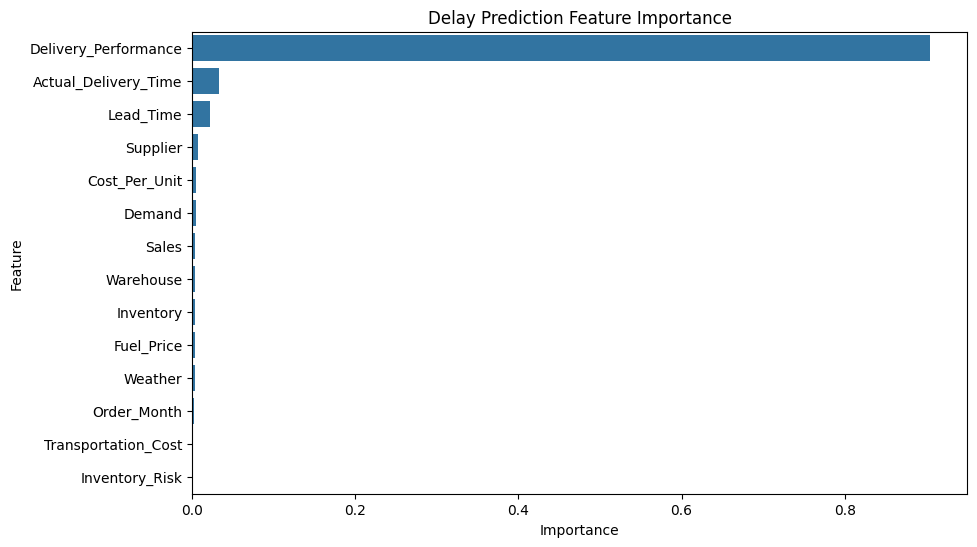

In [40]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=importance,

    x="Importance",

    y="Feature"

)

plt.title("Delay Prediction Feature Importance")

plt.show()

In [41]:

# SAVE MODEL


joblib.dump(

    xgb_model,

    "Delay_Prediction_Model.pkl"

)

print("Delay Model Saved")

Delay Model Saved


In [43]:

# EXPORT RESULTS


df.to_excel(

    "Supply_Chain_With_Delay_Predictions.xlsx",

    index=False

)



In [45]:

# INVENTORY OPTIMIZATION ENGINE
import shap
import plotly.express as px
import plotly.graph_objects as go



In [47]:

# SAFETY STOCK

service_factor = 1.65

df["Safety_Stock"] = (

    service_factor *

    df["Demand"].std() *

    np.sqrt(df["Lead_Time"])

)

df[["Demand","Lead_Time","Safety_Stock"]].head()

,Demand,Lead_Time,Safety_Stock
0,226,7,568.943423
1,351,3,372.460900
2,51,10,680.017456
3,86,7,568.943423
4,111,8,608.226103


In [48]:

# REORDER POINT

df["Reorder_Point"] = (

    (df["Demand"] * df["Lead_Time"])

    +

    df["Safety_Stock"]

)

df[["Demand","Lead_Time","Reorder_Point"]].head()

,Demand,Lead_Time,Reorder_Point
0,226,7,2150.943423
1,351,3,1425.460900
2,51,10,1190.017456
3,86,7,1170.943423
4,111,8,1496.226103


In [49]:

# INVENTORY STATUS


df["Inventory_Status"] = np.where(

    df["Inventory"] < df["Reorder_Point"],

    "REORDER",

    "SUFFICIENT"

)

df["Inventory_Status"].value_counts()

,count
Inventory_Status,
REORDER,968
SUFFICIENT,32


In [50]:

# EOQ

ordering_cost = 50

holding_cost = 5

df["EOQ"] = np.sqrt(

    (2 * df["Demand"] * ordering_cost)

    /

    holding_cost

)

df[["Demand","EOQ"]].head()

,Demand,EOQ
0,226,67.230945
1,351,83.785440
2,51,31.937439
3,86,41.472883
4,111,47.116876


In [51]:

# INVENTORY COST


df["Holding_Cost"] = (

    df["Inventory"]

    *

    holding_cost

)

df["Ordering_Cost"] = ordering_cost

df["Total_Inventory_Cost"] = (

    df["Holding_Cost"]

    +

    df["Ordering_Cost"]

)

df.head()

,Product_ID,Warehouse,Supplier,Order_Date,Delivery_Date,Demand,Inventory,Lead_Time,Transportation_Cost,Sales,...,Delivery_Performance,Demand_Category,Delay_Probability,Safety_Stock,Reorder_Point,Inventory_Status,EOQ,Holding_Cost,Ordering_Cost,Total_Inventory_Cost
0,P0001,2,2,2025-02-16,2025-02-24,226,402,7,3418.44,226,...,-1,2,0.997410,568.943423,2150.943423,REORDER,67.230945,2010,50,2060
1,P0002,2,0,2025-03-19,2025-03-23,351,110,3,1271.37,110,...,-1,0,0.997586,372.460900,1425.460900,REORDER,83.785440,550,50,600
2,P0003,3,1,2025-12-08,2025-12-20,51,562,10,1312.09,51,...,-2,1,0.998530,680.017456,1190.017456,REORDER,31.937439,2810,50,2860
3,P0004,1,1,2025-08-10,2025-08-20,86,29,7,4708.03,29,...,-3,1,0.998236,568.943423,1170.943423,REORDER,41.472883,145,50,195
4,P0005,0,0,2025-05-04,2025-05-14,111,419,8,1061.69,111,...,-2,1,0.998208,608.226103,1496.226103,REORDER,47.116876,2095,50,2145


In [52]:

# RECOMMENDATIONS


def inventory_recommendation(row):

    if row["Inventory"] < row["Reorder_Point"]:
        return "Order Immediately"

    elif row["Inventory"] < row["EOQ"]:
        return "Monitor Closely"

    else:
        return "Stock Healthy"


df["Recommendation"] = df.apply(

    inventory_recommendation,

    axis=1

)

df[

    ["Inventory",

     "Reorder_Point",

     "EOQ",

     "Recommendation"]

].head()

,Inventory,Reorder_Point,EOQ,Recommendation
0,402,2150.943423,67.230945,Order Immediately
1,110,1425.460900,83.785440,Order Immediately
2,562,1190.017456,31.937439,Order Immediately
3,29,1170.943423,41.472883,Order Immediately
4,419,1496.226103,47.116876,Order Immediately


In [53]:

# SUPPLIER SCORECARD


supplier_score = (

    df.groupby("Supplier")

    .agg(

        Avg_Lead_Time=("Lead_Time","mean"),

        Avg_Cost=("Transportation_Cost","mean"),

        Total_Sales=("Sales","sum"),

        Total_Demand=("Demand","sum")

    )

)

supplier_score["Supplier_Score"] = (

    supplier_score["Total_Sales"]

    /

    supplier_score["Avg_Lead_Time"]

)

supplier_score = supplier_score.sort_values(

    by="Supplier_Score",

    ascending=False

)

supplier_score

,Avg_Lead_Time,Avg_Cost,Total_Sales,Total_Demand,Supplier_Score
Supplier,,,,,
3,5.594697,2461.020606,54389,71203,9721.527420
1,5.584314,2761.578118,51504,69776,9222.977528
0,5.157658,2645.962748,46762,63081,9066.518777
2,6.023166,2640.550927,50511,70331,8386.121154


In [55]:

# SUPPLIER RANKING

supplier_score["Rank"] = range(

    1,

    len(supplier_score)+1

)

supplier_score

,Avg_Lead_Time,Avg_Cost,Total_Sales,Total_Demand,Supplier_Score,Rank
Supplier,,,,,,
3,5.594697,2461.020606,54389,71203,9721.527420,1
1,5.584314,2761.578118,51504,69776,9222.977528,2
0,5.157658,2645.962748,46762,63081,9066.518777,3
2,6.023166,2640.550927,50511,70331,8386.121154,4


In [56]:

# WAREHOUSE PERFORMANCE

warehouse_score = (

    df.groupby("Warehouse")

    .agg(

        Sales=("Sales","sum"),

        Demand=("Demand","sum"),

        Inventory=("Inventory","sum")

    )

)

warehouse_score["Performance_Score"] = (

    warehouse_score["Sales"]

    /

    warehouse_score["Demand"]

)

warehouse_score

,Sales,Demand,Inventory,Performance_Score
Warehouse,,,,
0,62783,81868,90317,0.766881
1,45581,64029,68357,0.711881
2,44771,62844,68186,0.712415
3,50031,65650,82154,0.762087


In [57]:

# RISK LEVEL


conditions = [

    df["Inventory"] < df["Reorder_Point"],

    df["Inventory"] < df["EOQ"]

]

choices = [

    "HIGH RISK",

    "MEDIUM RISK"

]

df["Inventory_Risk_Level"] = np.select(

    conditions,

    choices,

    default="LOW RISK"

)

df["Inventory_Risk_Level"].value_counts()

,count
Inventory_Risk_Level,
HIGH RISK,968
LOW RISK,32


In [58]:

fig = px.pie(

    df,

    names="Inventory_Status",

    title="Inventory Status Distribution"

)

fig.show()

In [59]:


fig = px.histogram(

    df,

    x="Inventory_Risk_Level",

    title="Inventory Risk Levels"

)

fig.show()

In [60]:

fig = px.bar(

    supplier_score.reset_index(),

    x="Supplier",

    y="Supplier_Score",

    title="Supplier Performance Ranking"

)

fig.show()

In [62]:

# SHAP EXPLAINABILITY


explainer = shap.TreeExplainer(

    model_demand

)

sample_data = X_test.sample(

    min(100, len(X_test)),

    random_state=42

)

shap_values = explainer.shap_values(

    sample_data

)



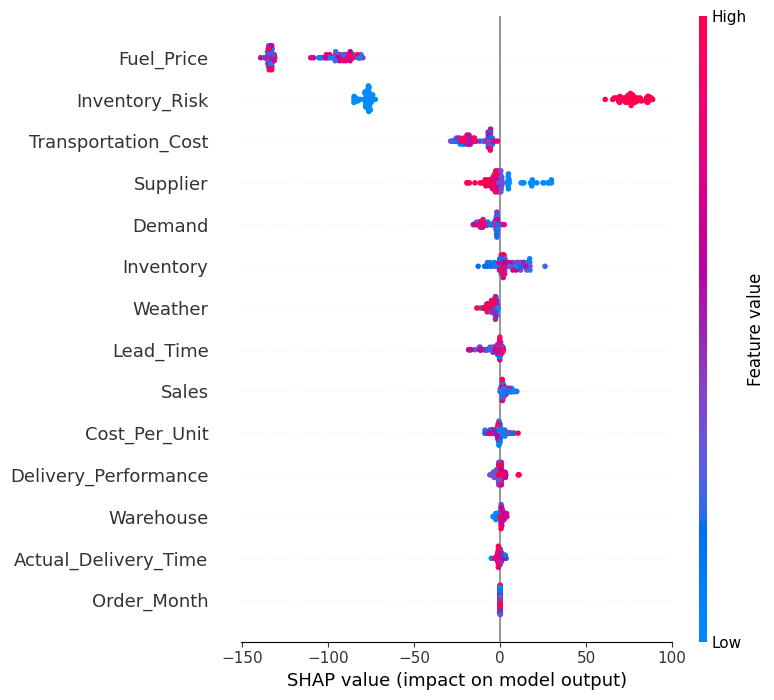

In [63]:

# SHAP SUMMARY

shap.summary_plot(

    shap_values,

    sample_data

)

In [64]:

# BUSINESS INSIGHTS


print("Total Orders:", len(df))

print("Average Demand:", round(df["Demand"].mean(),2))

print("Average Inventory:", round(df["Inventory"].mean(),2))

print("Average Transportation Cost:",
      round(df["Transportation_Cost"].mean(),2))

print("High Risk Products:",
      len(df[df["Inventory_Risk_Level"]=="HIGH RISK"]))

print("Reorder Required:",
      len(df[df["Inventory_Status"]=="REORDER"]))

Total Orders: 1000
Average Demand: 274.39
Average Inventory: 309.01
Average Transportation Cost: 2625.22
High Risk Products: 968
Reorder Required: 968


In [66]:

# SAVE RESULTS

df.to_excel(

    "Supply_Chain_Optimization_Results.xlsx",

    index=False

)

